In [3]:
import import_ipynb
import genetic_algorithm
import NSGA2
import simulated_annealing
from accuracy import calc_accuracy
from knn_evaluator import evaluate_knn
import pandas as pd

In [4]:
X_train_toxicity = pd.read_csv("../datasets/oral_toxicity/X_train.csv")
X_validation_toxicity = pd.read_csv("../datasets/oral_toxicity/X_validation.csv")
y_train_toxicity = pd.read_csv('../datasets/oral_toxicity/y_train.csv').to_numpy().ravel()
y_validation_toxicity  = pd.read_csv('../datasets/oral_toxicity/y_validation.csv').to_numpy().ravel()

In [5]:
# type(y_validation_toxicity.to_numpy().ravel())

0.9221681723419041 0.04296875
0.9235580264072273 0.0439453125
0.9305072967338429 0.0654296875
0.9159138290479499 0.0380859375
0.9214732453092426 0.0400390625
0.9346768589298123 0.0966796875
0.9318971507991661 0.09375
0.9360667129951356 0.142578125
0.935371785962474 0.1328125


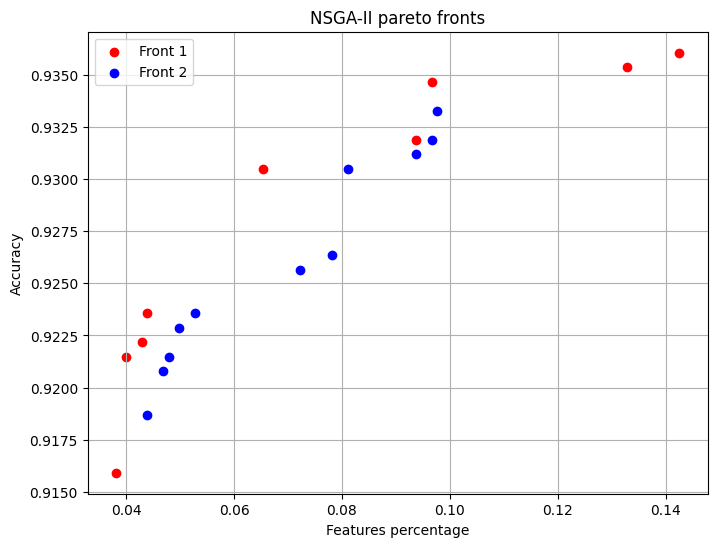

In [6]:
nsga = NSGA2.NSGA2(X_train_toxicity, y_train_toxicity, X_validation_toxicity, y_validation_toxicity, calc_accuracy_fn=evaluate_knn,
                   population_size=20, num_generations=3, feature_probability=0.05)
pareto = nsga.run()

In [7]:
sa =simulated_annealing.Simulated_Annealing(30,pareto[0].code,0.5,X_train_toxicity,y_train_toxicity,X_validation_toxicity,y_validation_toxicity,evaluate_knn)
sol, fitness,selected_percentage=sa.run()

In [8]:
fitness

0.9413370287526059

In [9]:
selected_percentage

0.04296875

In [10]:
ga = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,X_validation_toxicity,y_validation_toxicity,calc_accuracy_fn= evaluate_knn , population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10)
selected_features, fitness, history = ga.run()

No improvement for 10 generations


In [15]:
#type(X_train_toxicity[X_train_toxicity.columns[selected_features]].to_numpy())

numpy.ndarray

In [11]:
X_test_toxicity = pd.read_csv("../datasets/oral_toxicity/X_test.csv")
y_test_toxicity = pd.read_csv("../datasets/oral_toxicity/y_test.csv").to_numpy().ravel()

In [12]:
evaluate_knn(selected_features,X_train_toxicity,y_train_toxicity,X_test_toxicity,y_test_toxicity)

0.9238465814341301

In [15]:
X_train_d = pd.read_csv("../datasets/leukemia/X_train.csv")
X_validation_d = pd.read_csv("../datasets/leukemia/X_validation.csv")

y_train_d = pd.read_csv("../datasets/leukemia/y_train.csv").to_numpy().ravel()
y_validation_d = pd.read_csv("../datasets/leukemia/y_validation.csv").to_numpy().ravel()

In [ ]:
ga = genetic_algorithm.GA( X_train_toxicity ,y_train_toxicity ,X_validation_toxicity,y_validation_toxicity,calc_accuracy_fn= calc_accuracy , population_size = 30, num_generations = 20, tournament_size=4, mutation_probability = 0.1,alpha = 0.1,elitism_size = 5,patience = 10)
selected_features, fitness, history = ga.run()